In [116]:
# ============================================================
# Imports
# ============================================================

import pickle
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage
from scipy.ndimage import gaussian_filter

# ============================================================
# Global Parameters
# ============================================================

LAYER = "d4"         

RESOLUTION = 40       # occupancy grid size

GAUSSIAN_SIGMA = 1.5

SPI_THRESHOLD = 0.30

SPARSITY_THRESHOLD = 0.12

EPS = 1e-12

REPRESENTATION = "abs"    # abs, real, imag

In [117]:
# ============================================================
# Activation representations
# ============================================================

def get_representation(z, mode):

    if mode == "abs":
        return np.abs(z)

    elif mode == "real":
        return np.real(z)

    elif mode == "imag":
        return np.imag(z)

    elif mode == "phase":
        return np.angle(z)

    else:
        raise ValueError("Unknown mode")

In [118]:
# ============================================================
# Load trajectory results
# ============================================================

trajectory_path = "/Users/ais/Desktop/2026_Summer/2D-traj-results.pkl"

with open(trajectory_path, "rb") as f:
    traj_data = pickle.load(f)

print(type(traj_data))
print(traj_data.keys())


<class 'dict'>
dict_keys(['time', 'ground_truth', 'prediction', 'd1', 'z1', 'd2', 'z2', 'd3', 'z3', 'd4'])


In [119]:
# -------------------------------------------------------
# Select which trajectory to analyse
# -------------------------------------------------------
trajectory_idx = 0      # Change this to any value from 0 to 49

# Position for only one trajectory
positions = traj_data["prediction"][trajectory_idx]

# Activations for only one trajectory
activations = get_representation(
    traj_data[LAYER],
    REPRESENTATION
)[trajectory_idx]

print(f"Trajectory: {trajectory_idx}")
print("positions:", positions.shape)
print("activations:", activations.shape)

Trajectory: 0
positions: (500, 2)
activations: (500, 100)


In [120]:
# ============================================================
# Extract positions and neural activations
# ============================================================

print("Layer:", LAYER)
print("Positions:", positions.shape)
print("Activations:", activations.shape)
print("dtype:", activations.dtype)

Layer: d4
Positions: (500, 2)
Activations: (500, 100)
dtype: float32


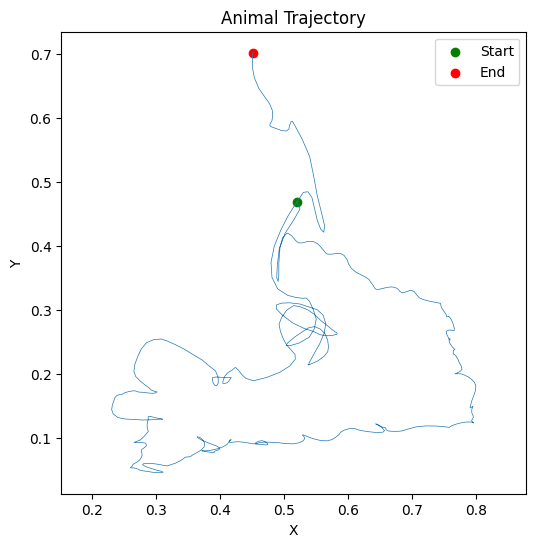

In [121]:
# ============================================================
# Plot trajectory
# ============================================================

plt.figure(figsize=(6,6))

plt.plot(
    positions[:,0],
    positions[:,1],
    lw=0.5
)

plt.scatter(
    positions[0,0],
    positions[0,1],
    color="green",
    label="Start"
)

plt.scatter(
    positions[-1,0],
    positions[-1,1],
    color="red",
    label="End"
)

plt.xlabel("X")

plt.ylabel("Y")

plt.title("Animal Trajectory")

plt.axis("equal")

plt.legend()

plt.show()

In [122]:
# ============================================================
# Occupancy Map
# ============================================================


def occupancy_map_2d(
    positions,
    resolution=40,
    sigma=1.5,
):
    """
    Returns BOTH occupancy counts and occupancy probability.
    """

    occ_counts, xedges, yedges = np.histogram2d(
        positions[:, 0],
        positions[:, 1],
        bins=resolution
    )

    occ_counts = occ_counts.astype(float)

    # Smooth occupancy counts
    occ_smooth = gaussian_filter(
        occ_counts,
        sigma=sigma
    )

    # Convert to probabilities
    occ_prob = occ_smooth / np.sum(occ_smooth)

    return occ_counts, occ_smooth, occ_prob, xedges, yedges

In [123]:
occ_counts, occ_smooth, occ_prob, xedges, yedges = occupancy_map_2d(
    positions,
    resolution=RESOLUTION,
    sigma=GAUSSIAN_SIGMA,
)

print("Counts :", occ_counts.shape)
print("Smooth :", occ_smooth.shape)
print("Prob   :", occ_prob.shape)

print()

print("Probability sum =", occ_prob.sum())

Counts : (40, 40)
Smooth : (40, 40)
Prob   : (40, 40)

Probability sum = 1.0


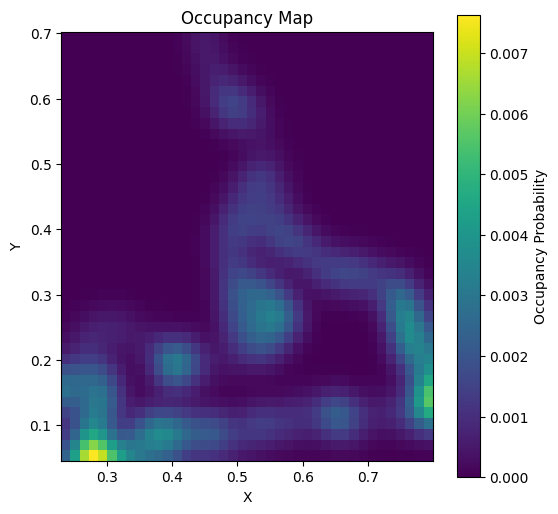

In [124]:
plt.figure(figsize=(6,6))

plt.imshow(
    occ_prob.T,
    origin="lower",
    extent=[
        xedges[0],
        xedges[-1],
        yedges[0],
        yedges[-1]
    ],
    cmap="viridis"
)

plt.colorbar(label="Occupancy Probability")

plt.xlabel("X")

plt.ylabel("Y")

plt.title("Occupancy Map")

plt.show()

In [125]:
# ============================================================
# Spike Histogram
# ============================================================

def spike_histogram_2d(
    activations,
    positions,
    neuron,
    xedges,
    yedges,
    sigma=1.5,
):

    response = activations[:, neuron]

    spike_counts, _, _ = np.histogram2d(
        positions[:,0],
        positions[:,1],
        bins=[xedges, yedges],
        weights=response
    )

    spike_smooth = gaussian_filter(
        spike_counts,
        sigma=sigma
    )

    return spike_counts, spike_smooth

In [126]:
print("prediction:", traj_data["prediction"].shape)
print("z1:", traj_data["z1"].shape)
print("z2:", traj_data["z2"].shape)
print("z3:", traj_data["z3"].shape)

prediction: (50, 500, 2)
z1: (50, 500, 100)
z2: (50, 500, 100)
z3: (50, 500, 100)


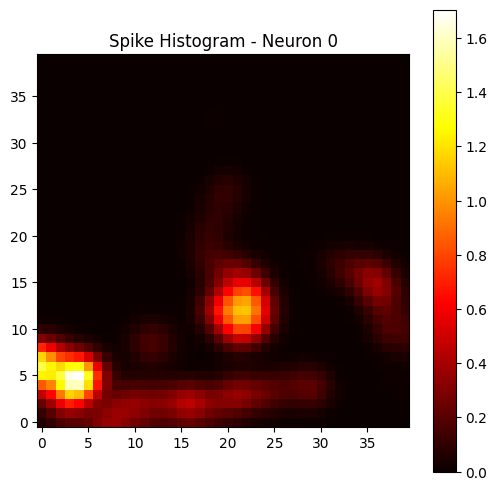

In [127]:
neuron = 0

_, spike_smooth = spike_histogram_2d(
    activations,
    positions,
    neuron,
    xedges,
    yedges
)

plt.figure(figsize=(6,6))

plt.imshow(
    spike_smooth.T,
    origin="lower",
    cmap="hot"
)

plt.title(f"Spike Histogram - Neuron {neuron}")

plt.colorbar()

plt.show()

In [128]:
# ============================================================
# Firing Rate Map
# ============================================================

def firing_rate_map_2d(
    activations,
    positions,
    neuron,
    occ_smooth,
    xedges,
    yedges,
    eps=1e-6,
):

    _, spike_smooth = spike_histogram_2d(
        activations,
        positions,
        neuron,
        xedges,
        yedges,
        sigma=GAUSSIAN_SIGMA,
    )

    rate_map = spike_smooth / (occ_smooth + eps)

    return rate_map

In [129]:
num_neurons = activations.shape[1]

firing_maps = np.zeros(
    (num_neurons, RESOLUTION, RESOLUTION)
)

for neuron in range(num_neurons):

    firing_maps[neuron] = firing_rate_map_2d(
        activations,
        positions,
        neuron,
        occ_smooth,
        xedges,
        yedges,
    )

print(firing_maps.shape)

(100, 40, 40)


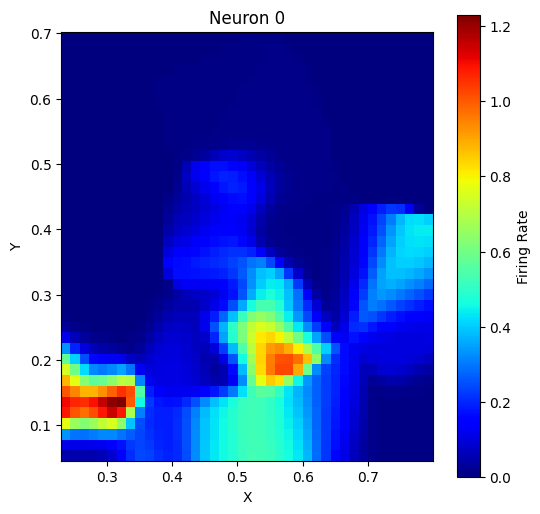

In [130]:
neuron = 0

plt.figure(figsize=(6,6))

plt.imshow(
    firing_maps[neuron].T,
    origin="lower",
    extent=[
        xedges[0],
        xedges[-1],
        yedges[0],
        yedges[-1]
    ],
    cmap="jet"
)

plt.colorbar(label="Firing Rate")

plt.title(f"Neuron {neuron}")

plt.xlabel("X")
plt.ylabel("Y")

plt.show()

In [131]:
# ============================================================
# Compute firing-rate maps
# ============================================================

num_neurons = activations.shape[1]

firing_maps = np.zeros(
    (num_neurons, RESOLUTION, RESOLUTION)
)

for neuron in range(num_neurons):

    firing_maps[neuron] = firing_rate_map_2d(
        activations,
        positions,
        neuron,
        occ_smooth,
        xedges,
        yedges,
    )

print(firing_maps.shape)

(100, 40, 40)


In [132]:
# ============================================================
# Spatial Information (Skaggs)
# ============================================================

def spatial_information(rate_map, occupancy, eps=1e-12):
    """
    Computes Skaggs Spatial Information (bits/spike).
    """

    rate = rate_map.copy()

    mean_rate = np.sum(rate * occupancy)

    if mean_rate < eps:
        return 0.0

    ratio = rate / (mean_rate + eps)

    valid = rate > eps

    info = np.sum(
        occupancy[valid]
        * ratio[valid]
        * np.log2(ratio[valid] + eps)
    )

    return info

In [133]:
si = spatial_information(
    firing_maps[neuron],
    occ_prob
)

print(f"Spatial Information = {si:.4f} bits/spike")

Spatial Information = 0.6365 bits/spike


In [134]:
# ============================================================
# Spatial Information for all neurons
# ============================================================

spatial_info = []

for neuron in range(firing_maps.shape[0]):

    si = spatial_information(
        firing_maps[neuron],
        occ_prob
    )

    spatial_info.append(si)

spatial_info = np.asarray(spatial_info)

print(spatial_info.shape)

print()

print("Mean :", spatial_info.mean())

print("Max  :", spatial_info.max())

print("Min  :", spatial_info.min())

(100,)

Mean : 0.6122093500623119
Max  : 1.7446722741564458
Min  : 0.09758550467864498


In [138]:
# ============================================================
# Sparsity
# ============================================================

def spatial_sparsity(rate_map, occupancy, eps=1e-12):
    """
    Compute spatial sparsity of one firing-rate map.
    """

    numerator = np.sum(rate_map * occupancy) ** 2

    denominator = np.sum(
        occupancy * (rate_map ** 2)
    )

    return numerator / (denominator + eps)

In [139]:
neuron = 0
sp = spatial_sparsity(
    firing_maps[neuron],
    occ_prob
)
print(f"Sparsity = {sp:.4f}")

Sparsity = 0.4851


In [140]:
# ============================================================
# Sparsity for all neurons
# ============================================================

sparsity = []

for neuron in range(firing_maps.shape[0]):

    sparsity.append(

        spatial_sparsity(
            firing_maps[neuron],
            occ_prob
        )

    )

sparsity = np.asarray(sparsity)

print()

print("Mean :", sparsity.mean())

print("Max  :", sparsity.max())

print("Min  :", sparsity.min())

print()

print(sparsity[:10])


Mean : 0.5783742657089287
Max  : 0.8923234916878643
Min  : 0.18571549512517585

[0.48505991 0.72854805 0.81396482 0.52890507 0.61118966 0.68459917
 0.76415192 0.41064352 0.36333774 0.80143162]


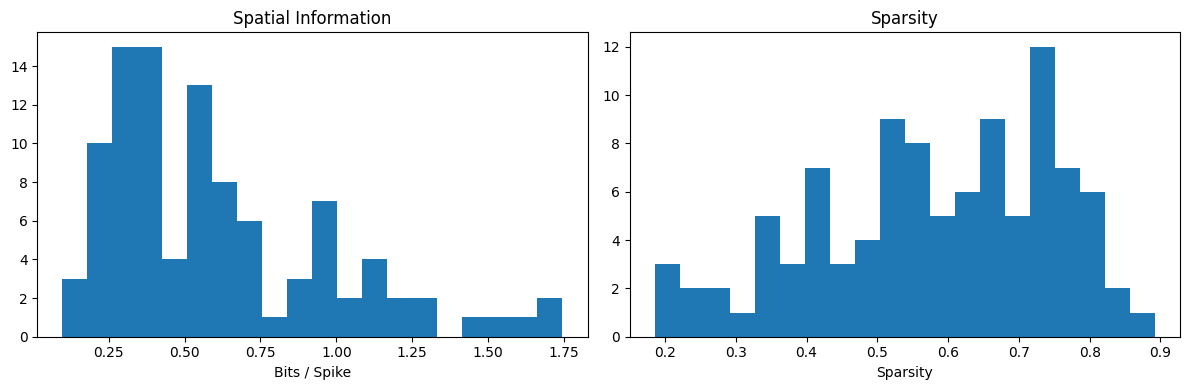

In [141]:
# ============================================================
# Metric distributions
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(spatial_info, bins=20)
ax[0].set_title("Spatial Information")
ax[0].set_xlabel("Bits / Spike")

ax[1].hist(sparsity, bins=20)
ax[1].set_title("Sparsity")
ax[1].set_xlabel("Sparsity")

plt.tight_layout()
plt.show()

In [142]:
# ============================================================
# Peak firing rate
# ============================================================

peak_rates = np.max(firing_maps, axis=(1,2))

print()

print("Peak firing rate")

print("----------------")

print("Mean :", peak_rates.mean())

print("Max  :", peak_rates.max())

print("Min  :", peak_rates.min())


Peak firing rate
----------------
Mean : 1.0763630463204255
Max  : 1.86918586440102
Min  : 0.3144679729381493


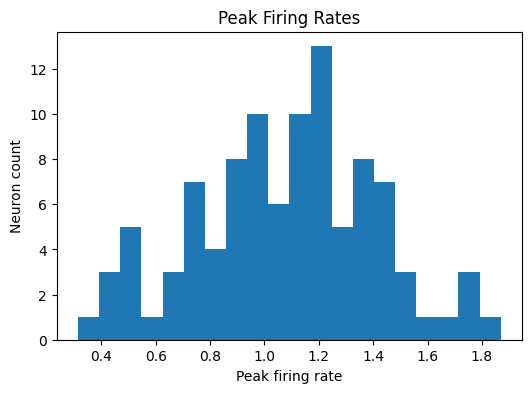

In [143]:
plt.figure(figsize=(6,4))

plt.hist(peak_rates, bins=20)

plt.xlabel("Peak firing rate")

plt.ylabel("Neuron count")

plt.title("Peak Firing Rates")

plt.show()

In [144]:
# ============================================================
# Inspect activations
# ============================================================

print("Layer:", LAYER)

print()

print("Shape:", activations.shape)

print()

print("Minimum :", activations.min())

print("Maximum :", activations.max())

print("Mean    :", activations.mean())

print("Std     :", activations.std())

Layer: d4

Shape: (500, 100)

Minimum : 3.964454e-07
Maximum : 2.064393
Mean    : 0.33443272
Std     : 0.3853092


In [145]:
def prepare_activations(traj_data, layer, representation):
    z = traj_data[layer]

    if representation == "abs":
        a = np.abs(z)
    elif representation == "real":
        a = np.real(z)
    elif representation == "imag":
        a = np.imag(z)
    elif representation == "phase":
        a = np.angle(z)
    else:
        raise ValueError("Unknown representation")

    return a.reshape(-1, a.shape[-1])

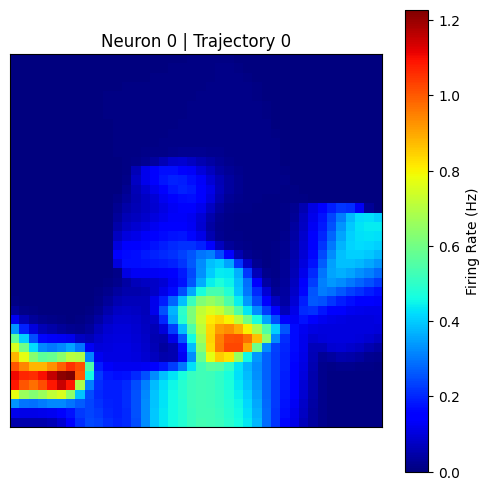

In [146]:
trajectory_idx = 0      # Change this to any trajectory (0-49)
neuron = 0

acts = get_representation(
    traj_data[LAYER],
    REPRESENTATION
)[trajectory_idx]

traj_positions = traj_data["prediction"][trajectory_idx]

rm = firing_rate_map_2d(
    acts,
    traj_positions,
    neuron,
    occ_smooth,
    xedges,
    yedges,
)

plt.figure(figsize=(6,6))
plt.imshow(
    rm.T,
    origin="lower",
    cmap="jet"
)
plt.colorbar(label="Firing Rate (Hz)")
plt.title(f"Neuron {neuron} | Trajectory {trajectory_idx}")
plt.xticks([])
plt.yticks([])
plt.show()

In [147]:
all_acts = get_representation(
    traj_data[LAYER],
    REPRESENTATION
)

all_firing_maps = []

for traj_idx in range(50):

    traj_positions = traj_data["prediction"][traj_idx]
    acts = all_acts[traj_idx]

    traj_maps = []

    for neuron in range(100):

        rm = firing_rate_map_2d(
            acts,
            traj_positions,
            neuron,
            occ_smooth,
            xedges,
            yedges,
        )

        traj_maps.append(rm)

    all_firing_maps.append(np.array(traj_maps))

all_firing_maps = np.array(all_firing_maps)

print(all_firing_maps.shape)

(50, 100, 40, 40)


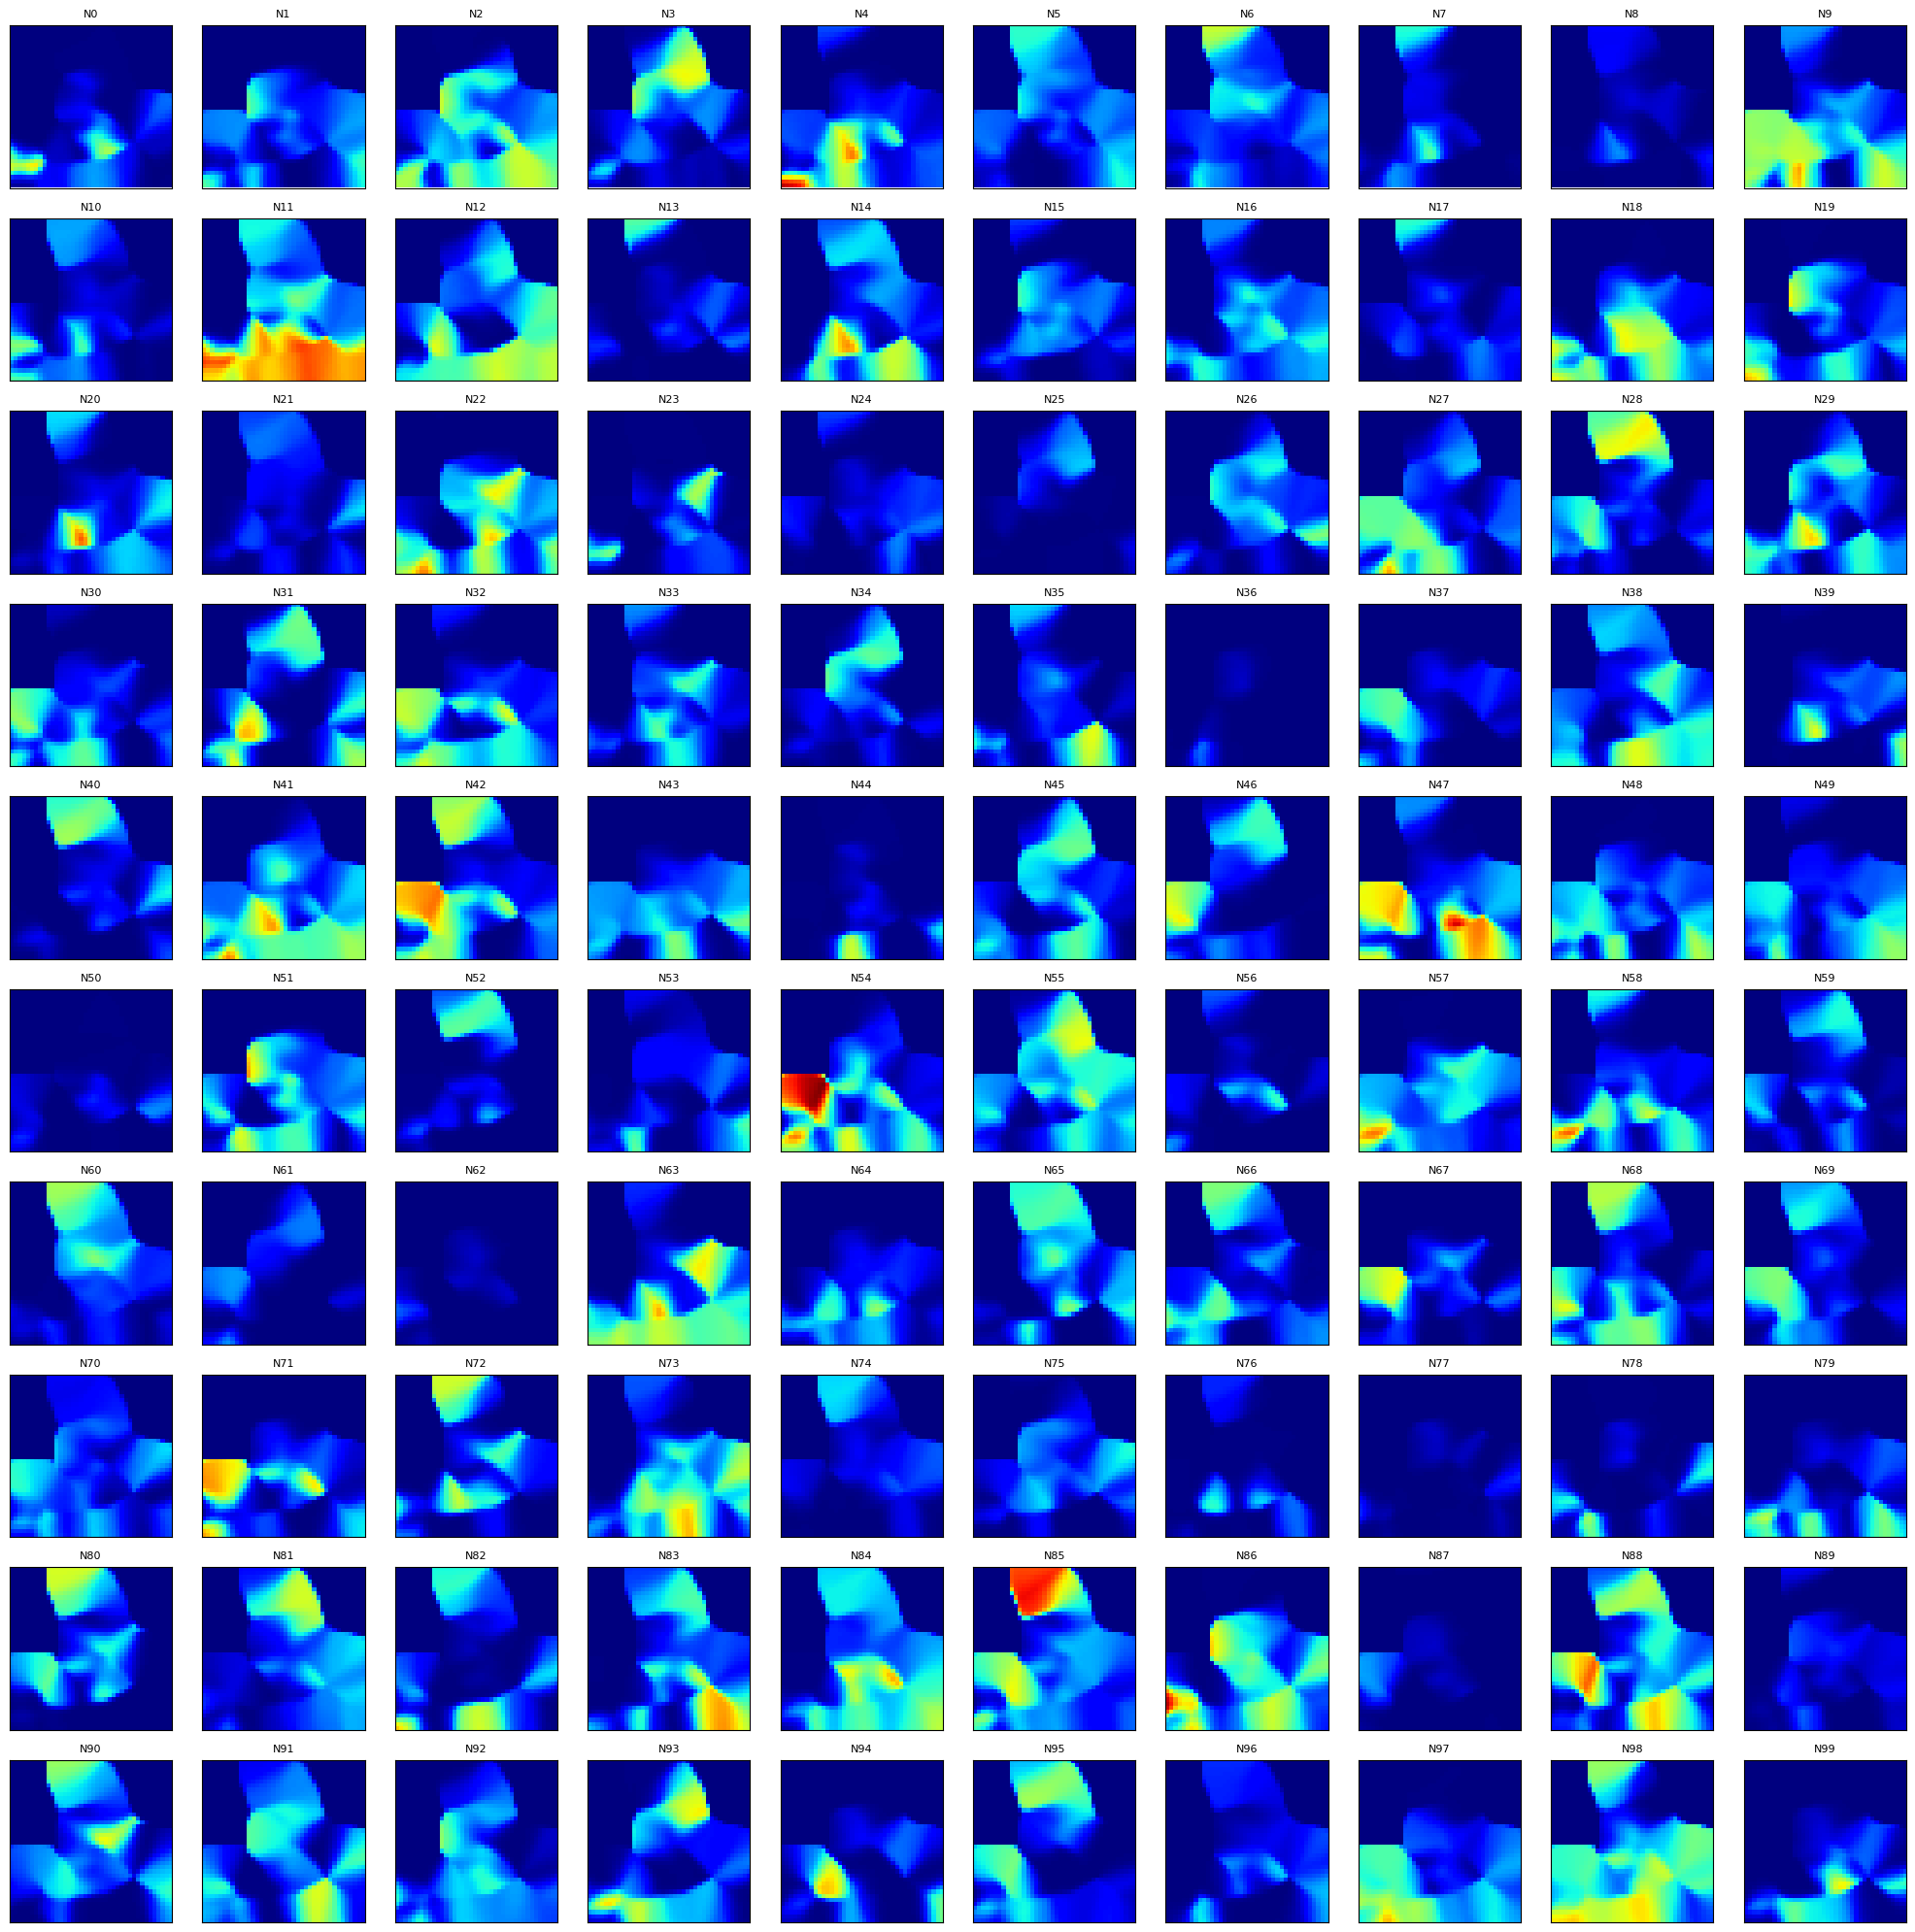

In [149]:
traj = 0

fig, axes = plt.subplots(10, 10, figsize=(20, 20))
axes = axes.flatten()

# Common color scale across all neurons in this trajectory
vmin = np.nanmin(all_firing_maps[traj])
vmax = np.nanmax(all_firing_maps[traj])

for neuron in range(100):

    ax = axes[neuron]

    ax.imshow(
        all_firing_maps[traj, neuron].T,
        origin="lower",
        cmap="jet",
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(f"N{neuron}", fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()